In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression

# Load the data
ohi_data = pd.read_csv(r"OHI scores copy.csv")
gdp_data = pd.read_csv(r"API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46 copy.csv", skiprows=4)


In [66]:
ohi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341124 entries, 0 to 341123
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   scenario     341124 non-null  int64  
 1   goal         341124 non-null  object 
 2   long_goal    341124 non-null  object 
 3   dimension    341124 non-null  object 
 4   region_id    341124 non-null  int64  
 5   region_name  341124 non-null  object 
 6   value        273575 non-null  float64
dtypes: float64(1), int64(2), object(4)
memory usage: 18.2+ MB


In [67]:
gdp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    flo

INITIAL CLEANING

In [68]:
# extract "goals and "dimensions" in order to calculate OHI health
# goal 'Index' and dimension 'score' is the final OHI result for a country.
# rename the value column to ocean_health for clarity
ohi_health = ohi_data[(ohi_data['goal'] == 'Index') & (ohi_data['dimension'] == 'score')].copy()
ohi_health = ohi_health[['region_name', 'scenario', 'value']].rename(columns={'value': 'ocean_health'})
 
# take the average resilience score across all sub-goals per country/year
ohi_res = ohi_data[ohi_data['dimension'] == 'resilience'].groupby(['region_name', 'scenario'])['value'].mean().reset_index()
ohi_res = ohi_res.rename(columns={'value': 'resilience_score'})

# combine both metrics, health and resilience
ohi_combined = pd.merge(ohi_health, ohi_res, on=['region_name', 'scenario'])

In [69]:
# prepare gdp data for merge by changing years from wide form to long form, only taking years from 2012-2024, ensure they are int 
year_range = [str(y) for y in range(2012, 2025) if str(y) in gdp_data.columns]
gdp_long = gdp_data.melt(id_vars=['Country Name'], 
                         value_vars=year_range, 
                         var_name='scenario', 
                         value_name='gdp_per_capita')
gdp_long['scenario'] = gdp_long['scenario'].astype(int)


In [70]:
# merge the OHI data with the GDP data
merged_data = pd.merge(ohi_combined, gdp_long, left_on=['region_name', 'scenario'], right_on=['Country Name', 'scenario'], how='inner')



# drop missing values 
final_data = merged_data.dropna(subset=['ocean_health', 'resilience_score', 'gdp_per_capita']).copy()

# Split the data into quantiles to see different trends amongst different tiers of GDP and assign them colors
final_data['gdp_tier'] = pd.qcut(final_data['gdp_per_capita'], q=3, labels=['Low', 'Mid', 'High']) 
tier_colors = {'Low': '#BA7517', 'Mid': '#1D9E75', 'High': '#185FA5'}

# Model features
features = ['resilience_score', 'gdp_per_capita']

MODEL 1  | Ridge Lasso Regressions to check for any linear relationships 

In [71]:

ridge_results = []
lasso_results = []
# Run regression models for every gdp tier 
for tier in ['Low', 'Mid', 'High']:
    subset = final_data[final_data['gdp_tier'] == tier]
    X_tier = subset[features]
    y_tier = subset['ocean_health']

    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X_tier, y_tier, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_t)
    X_test_s  = scaler.transform(X_test_t)

    ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
    ridge.fit(X_train_s, y_train_t)
    ridge_preds = ridge.predict(X_test_s)

    lasso = LassoCV(alphas=np.logspace(-3, 3, 100), cv=5, max_iter=10000)
    lasso.fit(X_train_s, y_train_t)
    lasso_preds = lasso.predict(X_test_s)

    ridge_results.append({'tier': tier, 'r2': r2_score(y_test_t, ridge_preds),
                          'mae': mean_absolute_error(y_test_t, ridge_preds),
                          'coef': ridge.coef_})
    lasso_results.append({'tier': tier, 'r2': r2_score(y_test_t, lasso_preds),
                          'mae': mean_absolute_error(y_test_t, lasso_preds),
                          'coef': lasso.coef_})
print(ridge_results)
print(lasso_results)

[{'tier': 'Low', 'r2': 0.03942756455823371, 'mae': 4.552470073188518, 'coef': array([ 2.82449549, -0.91801509])}, {'tier': 'Mid', 'r2': 0.23363620228163107, 'mae': 4.812357134260551, 'coef': array([2.49169407, 0.95211689])}, {'tier': 'High', 'r2': 0.17871227797467715, 'mae': 3.8684208394011326, 'coef': array([ 1.51671485, -0.99010368])}]
[{'tier': 'Low', 'r2': 0.034277377099671824, 'mae': 4.569092474777343, 'coef': array([ 2.99443701, -1.03944376])}, {'tier': 'Mid', 'r2': 0.23561218018046115, 'mae': 4.813673845809543, 'coef': array([2.67251237, 0.8996073 ])}, {'tier': 'High', 'r2': 0.18150938496852864, 'mae': 3.8630988864773723, 'coef': array([ 1.56360873, -1.02321682])}]


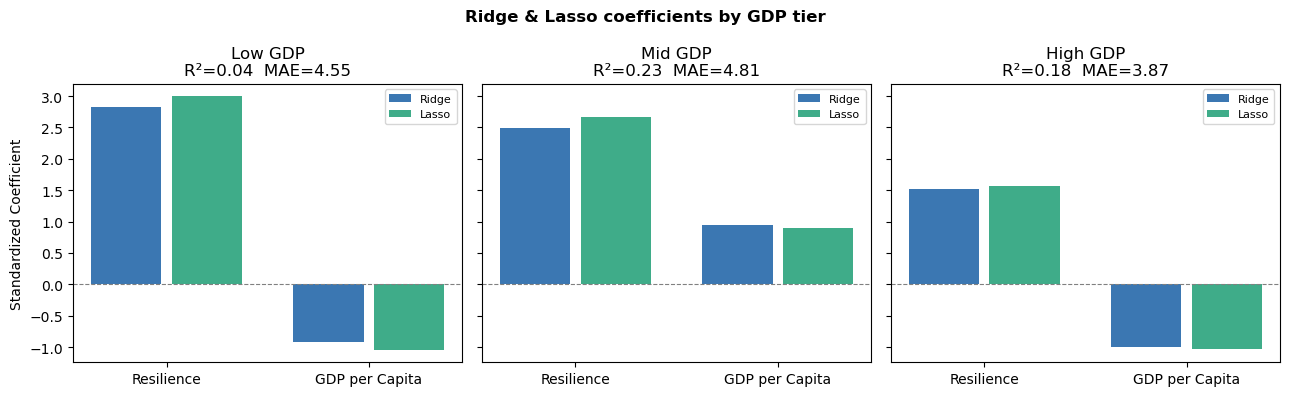

In [72]:
# Coefficients plot per tier
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
x = np.arange(2)

for ax, rr, lr in zip(axes, ridge_results, lasso_results):
    ax.bar(x - 0.2, rr['coef'], 0.35, label='Ridge', color='#185FA5', alpha=0.85)
    ax.bar(x + 0.2, lr['coef'], 0.35, label='Lasso', color='#1D9E75', alpha=0.85)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels(['Resilience', 'GDP per Capita'])
    ax.set_title(f"{rr['tier']} GDP\nR²={rr['r2']:.2f}  MAE={rr['mae']:.2f}")
    ax.legend(fontsize=8)

axes[0].set_ylabel('Standardized Coefficient')
plt.suptitle('Ridge & Lasso coefficients by GDP tier', fontweight='bold')
plt.tight_layout()
plt.show()

MODEL 2 | Support Vector Regression to check for non linearity, things like diminishing returns

In [73]:
svr_results = []

for tier in ['Low', 'Mid', 'High']:
    subset = final_data[final_data['gdp_tier'] == tier]
    X_tier = subset[features]
    y_tier = subset['ocean_health']

    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X_tier, y_tier, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_t)
    X_test_s  = scaler.transform(X_test_t)

    svr = SVR(kernel='rbf', C=10, epsilon=0.5)
    svr.fit(X_train_s, y_train_t)
    preds = svr.predict(X_test_s)

    svr_results.append({'tier': tier, 'r2': r2_score(y_test_t, preds),
                        'mae': mean_absolute_error(y_test_t, preds),
                        'y_test': y_test_t, 'preds': preds})
print(svr_results)

[{'tier': 'Low', 'r2': 0.08797635844671492, 'mae': 4.385461718212698, 'y_test': 653     64.22
220     69.63
302     65.81
595     70.07
1647    62.58
        ...  
437     65.89
716     61.97
31      63.35
1694    68.44
708     66.38
Name: ocean_health, Length: 114, dtype: float64, 'preds': array([63.92946374, 69.66638184, 67.32316806, 66.69378643, 63.94914942,
       69.16793746, 63.19401676, 66.91440703, 69.34892809, 69.15808347,
       69.3412263 , 66.4223518 , 71.40159011, 69.03924064, 68.36888874,
       70.20061652, 65.53078858, 68.81994486, 68.16224032, 67.65758022,
       69.66183083, 70.09585201, 68.66505771, 59.75062332, 67.738473  ,
       61.50686936, 70.61211415, 67.58463692, 69.88076446, 69.09638979,
       70.41212466, 65.0876261 , 62.85089943, 59.05691493, 67.3063337 ,
       71.87712229, 69.33758884, 68.89781964, 67.84948139, 68.34672609,
       70.59009873, 56.12900593, 69.48662176, 70.22203037, 67.56143081,
       65.71474762, 70.91745238, 69.66323563, 71.94228807, 6

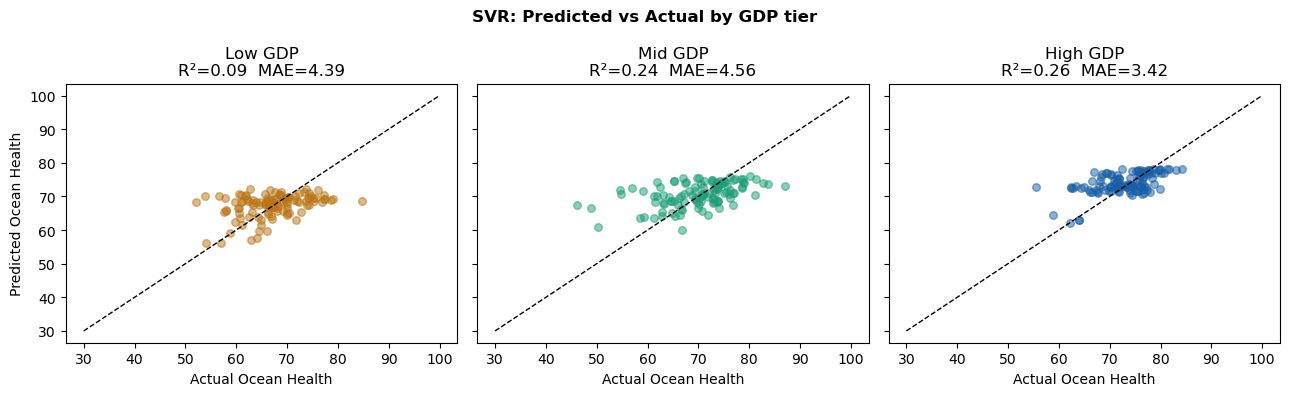

In [74]:
# Predicted vs Actual per tier
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, r in zip(axes, svr_results):
    ax.scatter(r['y_test'], r['preds'], alpha=0.5, color=tier_colors[r['tier']], s=30)
    ax.plot([30, 100], [30, 100], 'k--', linewidth=1)
    ax.set_xlabel('Actual Ocean Health')
    ax.set_title(f"{r['tier']} GDP\nR²={r['r2']:.2f}  MAE={r['mae']:.2f}")

axes[0].set_ylabel('Predicted Ocean Health')
plt.suptitle('SVR: Predicted vs Actual by GDP tier', fontweight='bold')
plt.tight_layout()
plt.show()

MODEL 3 | Random Forest model to explore possible relationships that aren't inehrently obvious

In [75]:
rf_results = []

for tier in ['Low', 'Mid', 'High']:
    subset = final_data[final_data['gdp_tier'] == tier]
    X_tier = subset[features]
    y_tier = subset['ocean_health']

    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X_tier, y_tier, test_size=0.2, random_state=42)

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train_t, y_train_t)
    preds = rf.predict(X_test_t)

    rf_results.append({'tier': tier, 'r2': r2_score(y_test_t, preds),
                       'mae': mean_absolute_error(y_test_t, preds),
                       'importances': rf.feature_importances_,
                       'y_test': y_test_t, 'preds': preds})
print(rf_results)




[{'tier': 'Low', 'r2': 0.217264078886107, 'mae': 3.8410710526315777, 'importances': array([0.5828461, 0.4171539]), 'y_test': 653     64.22
220     69.63
302     65.81
595     70.07
1647    62.58
        ...  
437     65.89
716     61.97
31      63.35
1694    68.44
708     66.38
Name: ocean_health, Length: 114, dtype: float64, 'preds': array([68.175 , 73.1901, 62.594 , 64.9289, 66.3487, 63.4407, 60.0857,
       68.7109, 73.059 , 68.5262, 68.5258, 60.601 , 72.1365, 69.2004,
       63.8282, 71.3156, 65.7271, 73.1736, 67.2619, 69.4157, 69.0735,
       67.6459, 63.6532, 58.4783, 65.5123, 64.8167, 69.706 , 68.7959,
       70.4232, 76.4417, 69.2543, 67.1721, 63.5899, 58.0274, 66.0214,
       72.1112, 72.0164, 69.9114, 64.5879, 61.6808, 74.4273, 57.3338,
       73.6854, 76.667 , 70.7755, 60.4736, 70.5898, 74.2467, 72.748 ,
       69.5708, 67.9968, 66.8052, 65.1053, 70.3523, 67.7708, 58.5433,
       71.3823, 68.1047, 69.3106, 69.3456, 74.512 , 63.7258, 67.004 ,
       58.7467, 59.0744, 66.2578,

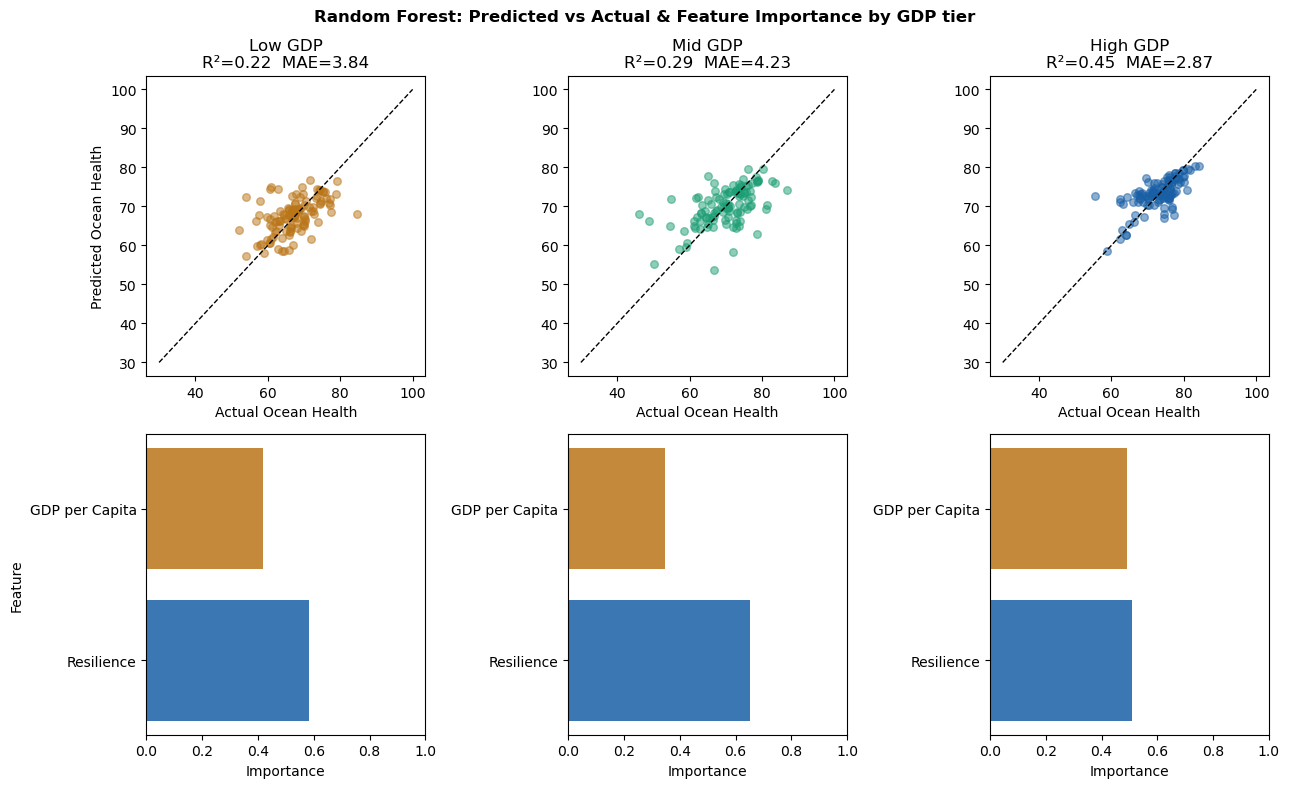

In [76]:
# Predicted vs Actual + Feature Importance per tier
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for i, r in enumerate(rf_results):
    # top row: predicted vs actual
    axes[0, i].scatter(r['y_test'], r['preds'], alpha=0.5,
                       color=tier_colors[r['tier']], s=30)
    axes[0, i].plot([30, 100], [30, 100], 'k--', linewidth=1)
    axes[0, i].set_xlabel('Actual Ocean Health')
    axes[0, i].set_title(f"{r['tier']} GDP\nR²={r['r2']:.2f}  MAE={r['mae']:.2f}")

    # bottom row: feature importance
    axes[1, i].barh(['Resilience', 'GDP per Capita'], r['importances'],
                    color=['#185FA5', '#BA7517'], alpha=0.85)
    axes[1, i].set_xlabel('Importance')
    axes[1, i].set_xlim(0, 1)

axes[0, 0].set_ylabel('Predicted Ocean Health')
axes[1, 0].set_ylabel('Feature')
plt.suptitle('Random Forest: Predicted vs Actual & Feature Importance by GDP tier',
             fontweight='bold')
plt.tight_layout()
plt.show()

Model Comparisons

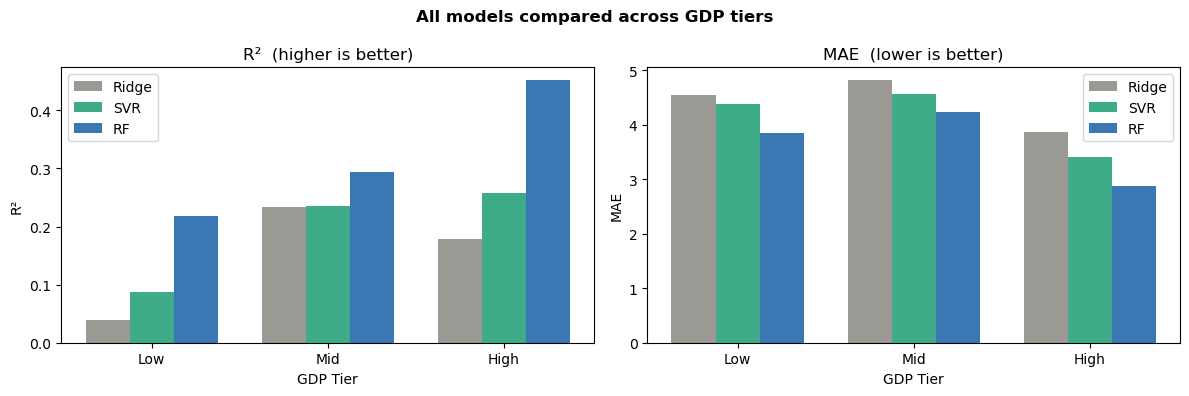

In [77]:
# comparisons between all models across tiers, to show which model has the best performance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tiers = ['Low', 'Mid', 'High']
x = np.arange(3)
width = 0.25
colors_m = ['#888780', '#1D9E75', '#185FA5']  # Ridge/Lasso, SVR, RF

for ax, metric in zip(axes, ['r2', 'mae']):
    for i, (results, label) in enumerate([(ridge_results, 'Ridge'),
                                           (svr_results,   'SVR'),
                                           (rf_results,    'RF')]):
        vals = [r[metric] for r in results]
        ax.bar(x + (i - 1) * width, vals, width, label=label,
               color=colors_m[i], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(tiers)
    ax.set_xlabel('GDP Tier')
    ax.set_ylabel('R²' if metric == 'r2' else 'MAE')
    ax.set_title(f"{'R²  (higher is better)' if metric == 'r2' else 'MAE  (lower is better)'}")
    ax.legend()

plt.suptitle('All models compared across GDP tiers', fontweight='bold')
plt.tight_layout()
plt.show()